In [2]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loas=ding the dataset
df = pd.read_csv("../data/cardio_train.csv", sep=";")

df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [4]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [7]:
df.shape

(70000, 13)

In [8]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
# checkin for duplicated rows
df.duplicated().value_counts

<bound method IndexOpsMixin.value_counts of 0        False
1        False
2        False
3        False
4        False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Length: 70000, dtype: bool>

In [10]:
df['cardio'].value_counts()


cardio
0    35021
1    34979
Name: count, dtype: int64

In [11]:
pd.crosstab(df['smoke'], df['cardio'], normalize='index')


cardio,0,1
smoke,,
0,0.497893,0.502107
1,0.525207,0.474793


In [12]:
df['cholesterol'].value_counts()



cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

<Axes: xlabel='cholesterol', ylabel='count'>

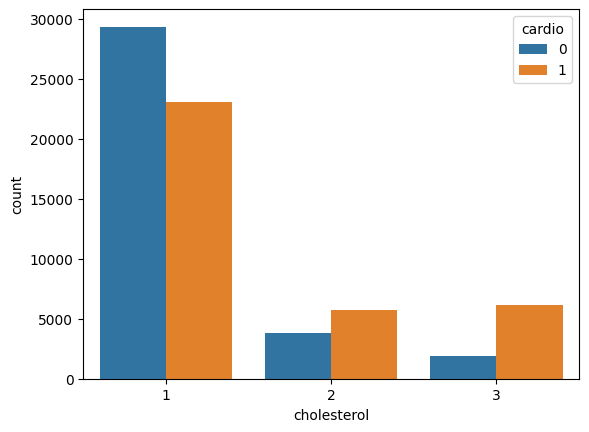

In [13]:
sns.countplot(x='cholesterol', hue='cardio', data=df)


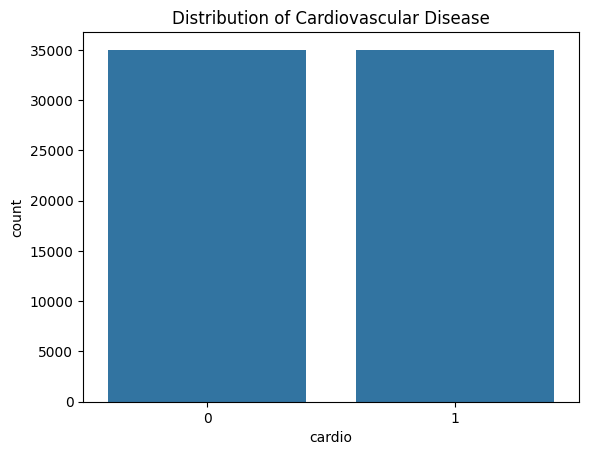

In [14]:
sns.countplot(x='cardio', data=df)
plt.title("Distribution of Cardiovascular Disease")
plt.show()


The barchart shows the data is balanced#

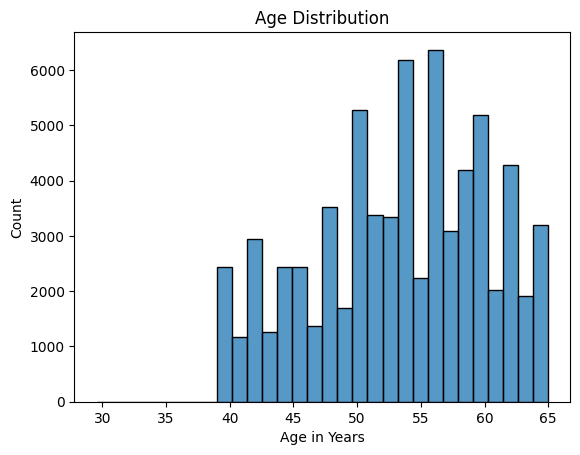

In [15]:
sns.histplot(df['age']/365, bins=30)
plt.title("Age Distribution")
plt.xlabel("Age in Years")
plt.show()

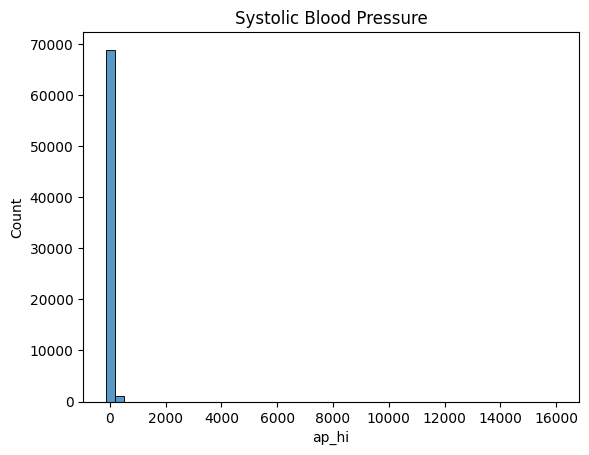

In [16]:
sns.histplot(df['ap_hi'], bins=50)
plt.title("Systolic Blood Pressure")
plt.show()


In [17]:
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)


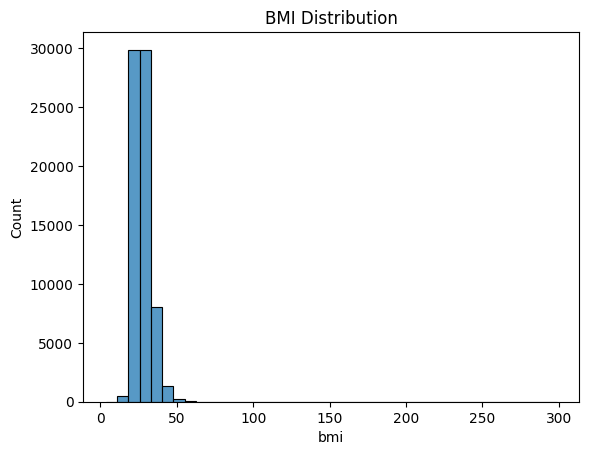

In [18]:
sns.histplot(df['bmi'], bins=40)
plt.title("BMI Distribution") 
plt.show()


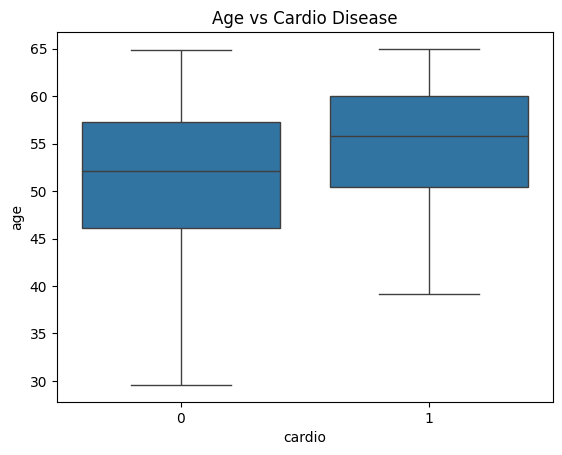

In [19]:
sns.boxplot(x='cardio', y=df['age']/365, data=df)
plt.title("Age vs Cardio Disease")
plt.show()


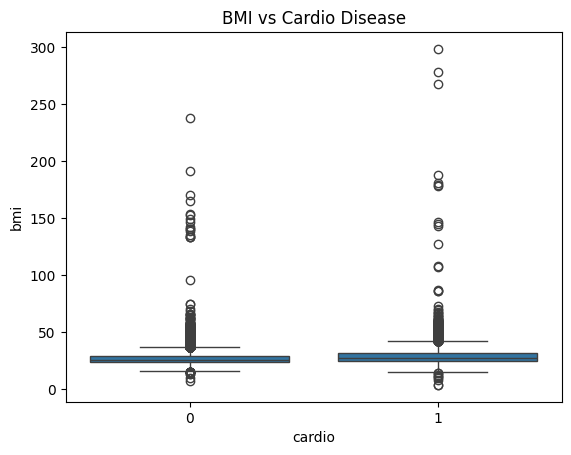

In [20]:
sns.boxplot(x='cardio', y='bmi', data=df)
plt.title("BMI vs Cardio Disease")
plt.savefig("boxplot")


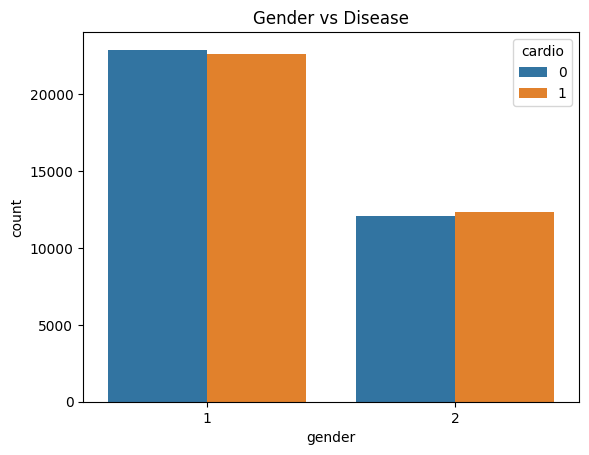

In [21]:
sns.countplot(x='gender', hue='cardio', data=df)
plt.title("Gender vs Disease")
plt.show()


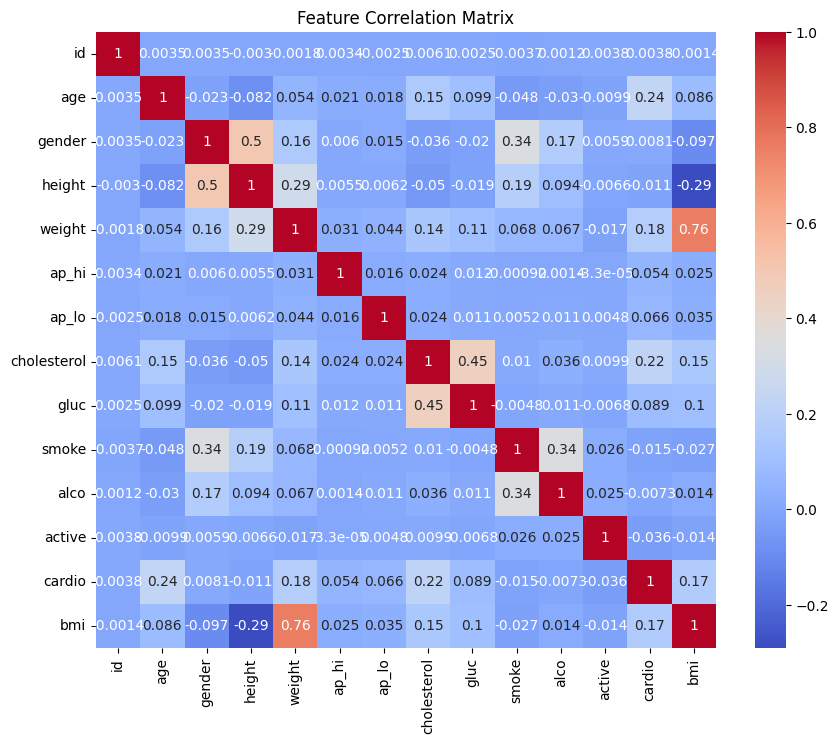

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


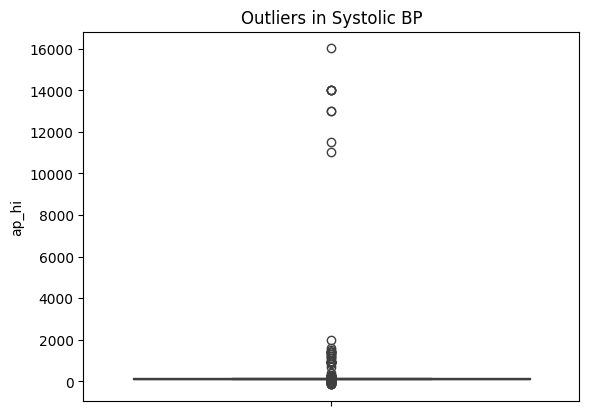

In [23]:
sns.boxplot(df['ap_hi'])
plt.title("Outliers in Systolic BP")
plt.show()


In [24]:
df_new = pd.DataFrame(df, columns=["age","height", "weight", "cholesterol", "bmi"])
df_new


,age,height,weight,cholesterol,bmi
0,18393,168,62.0,1,21.967120
1,20228,156,85.0,3,34.927679
2,18857,165,64.0,3,23.507805
3,17623,169,82.0,1,28.710479
4,17474,156,56.0,1,23.011177
...,...,...,...,...,...
69995,19240,168,76.0,1,26.927438
69996,22601,158,126.0,2,50.472681
69997,19066,183,105.0,3,31.353579
69998,22431,163,72.0,1,27.099251


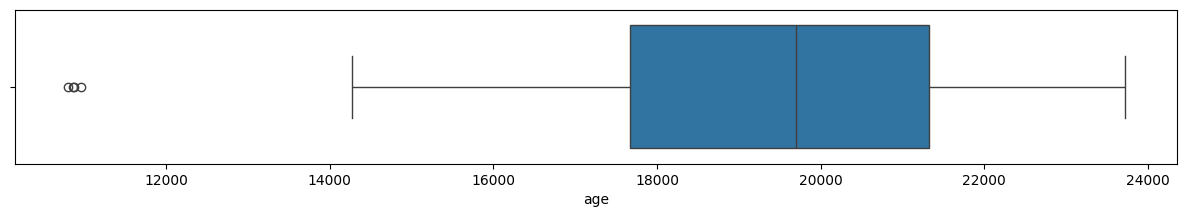

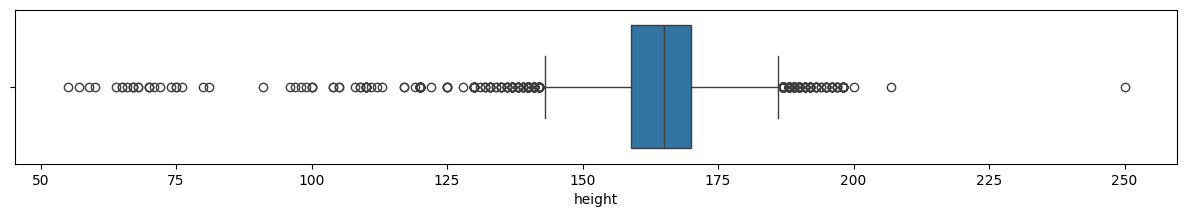

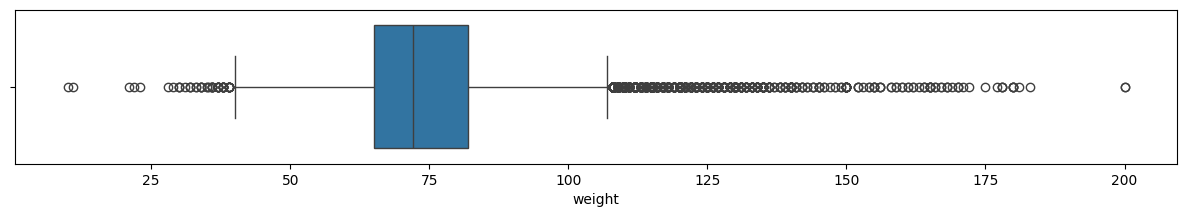

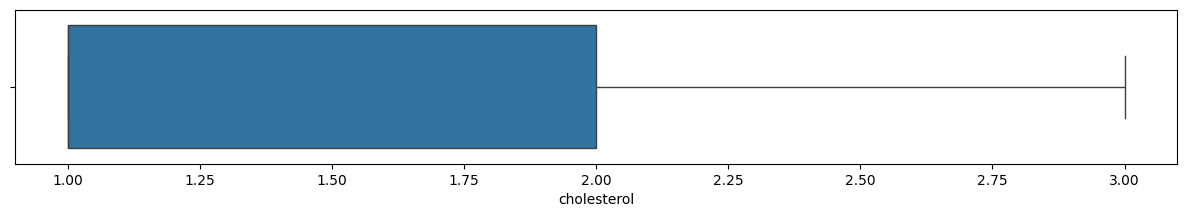

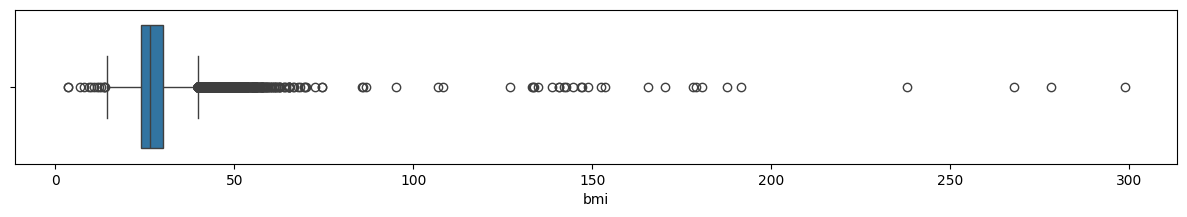

In [25]:
for column in df_new:
    plt.figure(figsize = (15,2))
    sns.boxplot(data = df_new, x = column)

In [26]:
q1 = np.quantile(df_new["age"], 0.25)
q3 = np.quantile(df_new["age"], 0.75)
iqr = q3 - q1

lower_limit = q1 - (1.5 * iqr)
upper_limit = q3 + (1.5 * iqr)
print(lower_limit, upper_limit)

index_list = df_new.index[(df_new["age"] < lower_limit) | (df_new["age"] > upper_limit)]
print(iqr)
print(index_list)

12169.5 26821.5
3663.0
Index([6219, 22343, 30666, 55905], dtype='int64')


In [ ]:
sns.boxplot(x='age', y='bmi', data=df_)

In [46]:
def remove_outliers(df_new, column):
    q1 = np.quantile(df_new[column], 0.25)
    q3 = np.quantile(df_new[column], 0.75)
    iqr = q3 - q1
    lower_limit = q1 - (1.5 * iqr)
    upper_limit = q3 + (1.5 * iqr)
    df_cleaned = df_new.drop(df_new[(df_new[column] < lower_limit) | (df_new[column] > upper_limit)].index)
    return df_cleaned
# Applying the outlier removal
df_cleaned = remove_outliers(df_new, "age")
df_cleaned = remove_outliers(df_cleaned, "height")
df_cleaned = remove_outliers(df_cleaned, "weight")
df_cleaned = remove_outliers(df_cleaned, "bmi")

df_cleaned

,age,height,weight,cholesterol,bmi
0,18393,168,62.0,1,21.967120
1,20228,156,85.0,3,34.927679
2,18857,165,64.0,3,23.507805
3,17623,169,82.0,1,28.710479
4,17474,156,56.0,1,23.011177
...,...,...,...,...,...
69994,21074,165,80.0,1,29.384757
69995,19240,168,76.0,1,26.927438
69997,19066,183,105.0,3,31.353579
69998,22431,163,72.0,1,27.099251


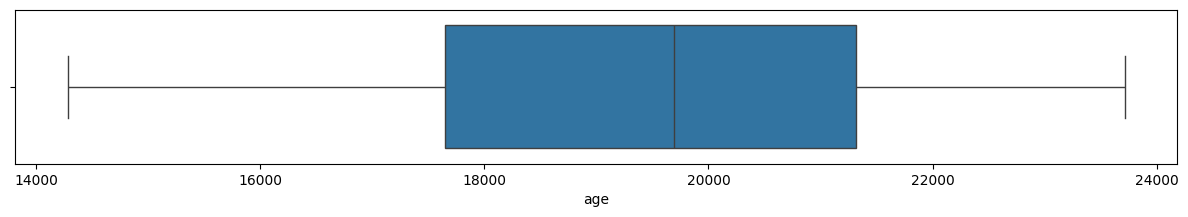

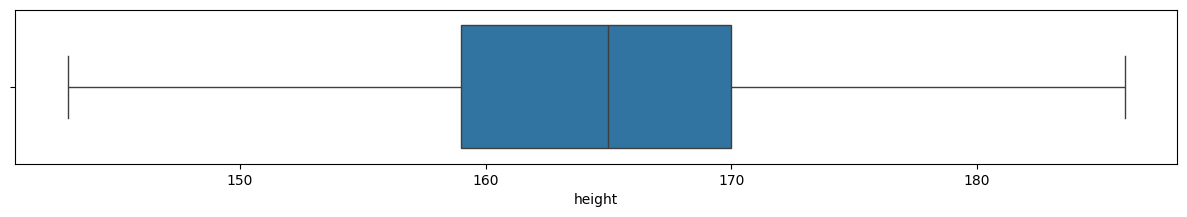

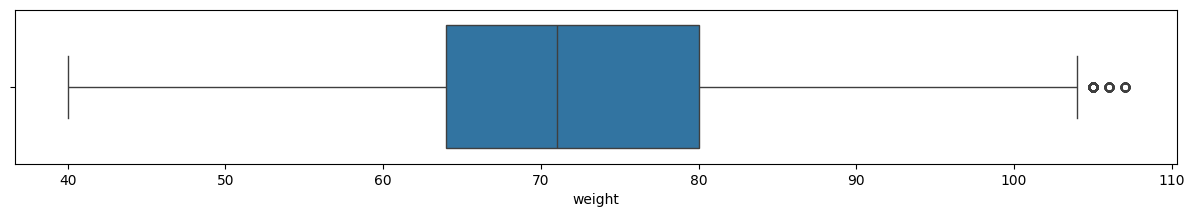

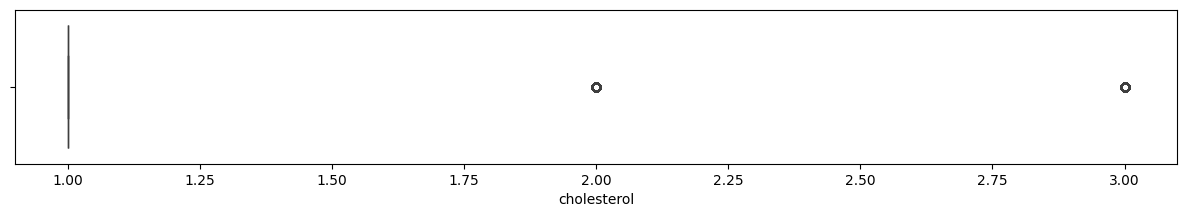

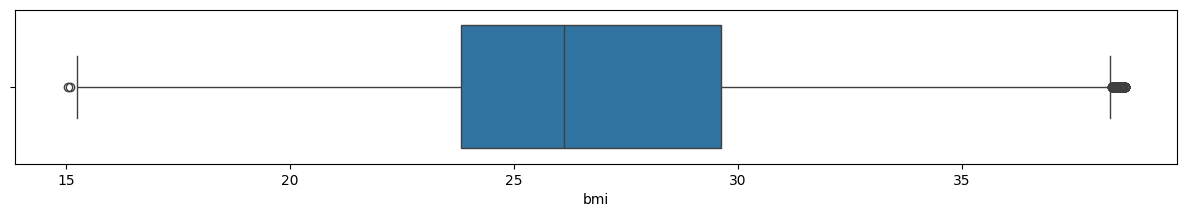

In [45]:
for column in df_cleaned:
    plt.figure(figsize = (15,2))
    sns.boxplot(data = df_cleaned, x = column)